In [4]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [5]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [6]:
X_test = joblib.load("../data/processed/X_test.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

model = joblib.load("../models/random_forest.pkl")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model: Random Forest")
print()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Model: Random Forest

Accuracy: 0.7803333333333333
Precision: 0.5029051000645578
Recall: 0.5870384325546345
F1: 0.5417246175243393
ROC-AUC: 0.7756541571609161


In [7]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.50      0.59      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.79      6000



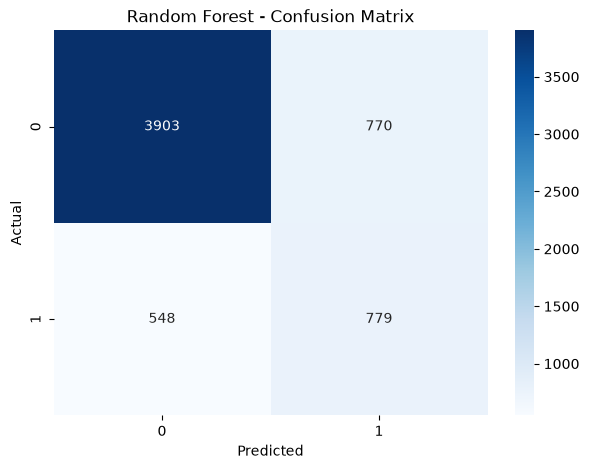

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

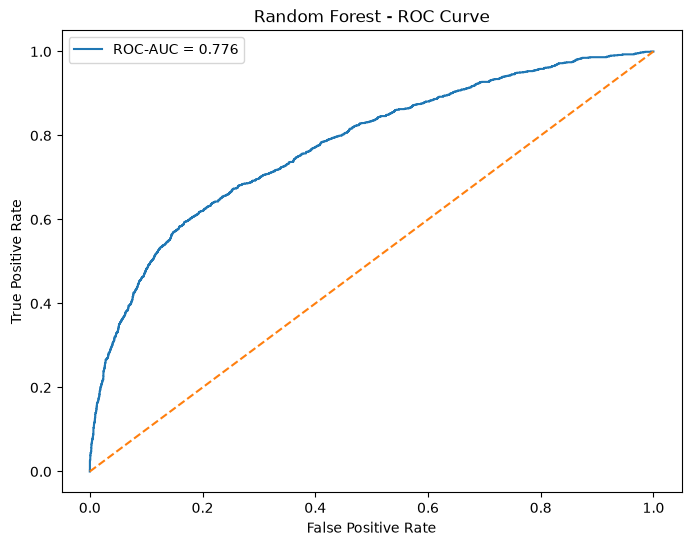

In [9]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")

plt.legend()

plt.show()

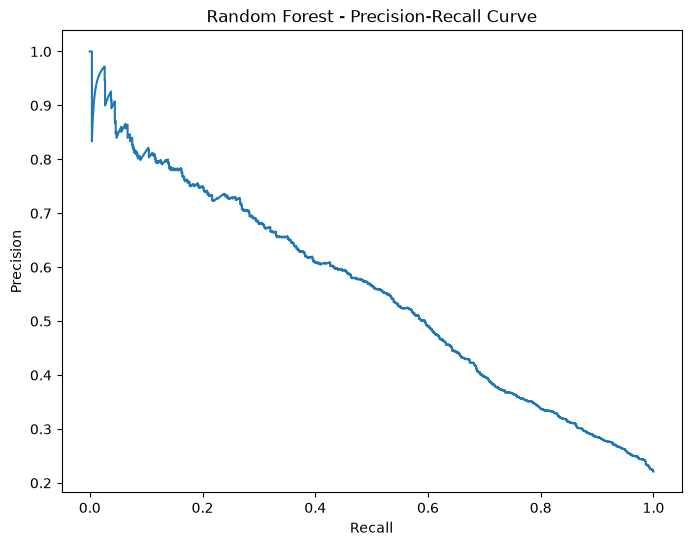

In [10]:
precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest - Precision-Recall Curve")

plt.show()

In [11]:
threshold_results = []

for threshold in np.arange(0.1, 1.0, 0.1):

    predictions = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.1,0.221167,1.000000,0.362222
1,0.2,0.239349,0.986436,0.385227
2,0.3,0.296240,0.878674,0.443093
3,0.4,0.391413,0.707611,0.504026
4,0.5,0.502905,0.587038,0.541725
5,0.6,0.572559,0.490580,0.528409
6,0.7,0.618818,0.386586,0.475881
7,0.8,0.705545,0.278071,0.398919
8,0.9,0.808917,0.095705,0.171159
